# 05 – Motif Analysis

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Replicates **Kaluza et al. (2010) Figure 4** — directed 3-node motif distribution and Z-score profile.

A **motif** is a small subgraph pattern that appears significantly more (or less) often in a real network than in random networks with the same degree sequence.  Milo et al. (2002) defined 16 directed triadic isomorphism classes (the *triadic census*); class 003 (no edges) is excluded, leaving **15 non-null triad types**.

### Method
1. Compute the **triadic census** for the real directed network with `nx.triadic_census()`
2. Generate **N_rand = 100** random graphs via degree-preserving edge rewiring (`nx.directed_edge_swap`), compute their census
3. Compute **Z-scores**: $Z_i = (X_i^{\text{real}} - \langle X_i^{\text{rand}}\rangle) / \sigma_i^{\text{rand}}$
4. Compare 2015 vs 2025 profiles and paper Fig. 4 baselines

> **Note**: Motif analysis requires only the directed edge list — no per-ship-type breakdown needed.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

print('Imports OK. NetworkX', nx.__version__)


Imports OK. NetworkX 3.4.2


## 1. Load Data and Build Directed Graphs

In [2]:
DATA_2015 = '../EdgeList/shipping_network_2015.csv'
DATA_2025 = '../EdgeList/shipping_network_2025.csv'

df_2015 = pd.read_csv(DATA_2015)
df_2025 = pd.read_csv(DATA_2025)

# Build directed unweighted graphs (motif analysis ignores weights)
Gd_2015 = nx.from_pandas_edgelist(df_2015, 'source', 'target',
                                   create_using=nx.DiGraph())
Gd_2025 = nx.from_pandas_edgelist(df_2025, 'source', 'target',
                                   create_using=nx.DiGraph())

for year, G in [('2015', Gd_2015), ('2025', Gd_2025)]:
    print(f'{year}: {G.number_of_nodes():,} nodes, '
          f'{G.number_of_edges():,} directed edges'
          f'  reciprocity={nx.reciprocity(G):.4f}')


2015: 7,097 nodes, 188,545 directed edges  reciprocity=0.4540
2025: 7,717 nodes, 182,300 directed edges  reciprocity=0.4696


## 2. Triadic Census — Background

The **triadic census** (Holland & Leinhardt 1970) counts how many ordered triples of nodes (i, j, k) fall into each of the 16 directed isomorphism classes.

| Code | Name | Description |
|------|------|-------------|
| 003  | null | no edges |
| 012  | arc  | 1 arc |
| 102  | mutual | 1 reciprocated pair |
| 021D | out-star | 2 arcs, divergent |
| 021U | in-star  | 2 arcs, convergent |
| 021C | 2-path   | 2 arcs, chain |
| 111D | t-arc D  | 1 mutual + 1 arc, divergent |
| 111U | t-arc U  | 1 mutual + 1 arc, convergent |
| 030T | 3-cycle T | 3 arcs, transitive |
| 030C | 3-cycle C | 3 arcs, cyclic |
| 201  | mutual pair | 2 mutuals |
| 120D | down | 2 mutuals + 1 arc, divergent |
| 120U | up   | 2 mutuals + 1 arc, convergent |
| 120C | cycle | 2 mutuals + 1 arc, chain |
| 210  | almost full | 5 arcs |
| 300  | complete triad | 3 mutual pairs |

We exclude **003** (vacuous); the remaining **15 types** are our motifs.

Kaluza et al. Fig. 4 uses 13 types (the connected, non-trivial ones); types 012 and 102 are omitted there as they involve disconnected components in the 3-node subgraph.  We include all 15 for completeness and highlight the 13 the paper reports.

## 3. Compute Triadic Census on Real Networks

In [3]:
# All 15 non-null triad types (in canonical order)
TRIAD_TYPES = [
    '012', '102', '021D', '021U', '021C',
    '111D', '111U', '030T', '030C', '201',
    '120D', '120U', '120C', '210', '300',
]
# The 13 motif types the paper (Kaluza Fig. 4) focuses on
PAPER_13 = [
    '021D', '021U', '021C', '111D', '111U',
    '030T', '030C', '201', '120D', '120U',
    '120C', '210', '300',
]


def get_census(G):
    """Return ordered dict of all 15 non-null triad counts."""
    full = nx.triadic_census(G)
    return {t: full.get(t, 0) for t in TRIAD_TYPES}


print('Computing triadic census on real networks …')
census_2015 = get_census(Gd_2015)
census_2025 = get_census(Gd_2025)

total_2015 = sum(census_2015.values())
total_2025 = sum(census_2025.values())

df_census = pd.DataFrame({
    'Triad': TRIAD_TYPES,
    'Count 2015': [census_2015[t] for t in TRIAD_TYPES],
    'Freq 2015':  [census_2015[t]/total_2015 for t in TRIAD_TYPES],
    'Count 2025': [census_2025[t] for t in TRIAD_TYPES],
    'Freq 2025':  [census_2025[t]/total_2025 for t in TRIAD_TYPES],
    'Paper motif': ['★' if t in PAPER_13 else '' for t in TRIAD_TYPES],
})
df_census['Freq 2015'] = df_census['Freq 2015'].map('{:.4%}'.format)
df_census['Freq 2025'] = df_census['Freq 2025'].map('{:.4%}'.format)

print()
print(df_census.to_string(index=False))


Computing triadic census on real networks …

Triad  Count 2015 Freq 2015  Count 2025 Freq 2025 Paper motif
  012   699285081  69.2896%   719766316  68.2294%            
  102   287342225  28.4717%   315831311  29.9389%            
 021D     2318915   0.2298%     1968155   0.1866%           ★
 021U     2502626   0.2480%     2043509   0.1937%           ★
 021C     4496812   0.4456%     3700025   0.3507%           ★
 111D     4581487   0.4540%     3866197   0.3665%           ★
 111U     4286981   0.4248%     3821197   0.3622%           ★
 030T      341534   0.0338%      291128   0.0276%           ★
 030C       70013   0.0069%       56840   0.0054%           ★
  201     2160309   0.2141%     1934733   0.1834%           ★
 120D      265830   0.0263%      229506   0.0218%           ★
 120U      232541   0.0230%      217851   0.0207%           ★
 120C      344592   0.0341%      297349   0.0282%           ★
  210      683953   0.0678%      614666   0.0583%           ★
  300      307940   0.030

## 4. Null Model — Degree-Preserving Random Networks

We generate **N_rand = 100** random networks by repeatedly swapping random pairs of edges while preserving each node's in- and out-degree (`nx.directed_edge_swap`, 10·|E| swaps = well-mixed).

For each random network we compute the triadic census, giving a null distribution for each triad type.

In [4]:
N_RAND  = 100    # number of random networks
N_SWAP_FACTOR = 10  # swaps per edge


def random_census_distribution(G, n_rand=N_RAND, swap_factor=N_SWAP_FACTOR, seed=0):
    """Generate n_rand degree-preserving random graphs and collect triadic census.
    Returns dict: triad_type -> list of counts (length n_rand).
    """
    rng = np.random.default_rng(seed)
    n_swaps = swap_factor * G.number_of_edges()
    rand_counts = {t: [] for t in TRIAD_TYPES}

    for i in range(n_rand):
        H = G.copy()
        nx.directed_edge_swap(H, nswap=n_swaps, max_tries=n_swaps * 10,
                              seed=int(rng.integers(1e6)))
        c = get_census(H)
        for t in TRIAD_TYPES:
            rand_counts[t].append(c[t])
        if (i + 1) % 20 == 0:
            print(f'  {i+1}/{n_rand} random networks done')

    return rand_counts


print('Generating null model for 2015 (100 rewirings) …')
rand_2015 = random_census_distribution(Gd_2015, seed=42)
print('\nGenerating null model for 2025 (100 rewirings) …')
rand_2025 = random_census_distribution(Gd_2025, seed=43)
print('\nDone.')


Generating null model for 2015 (100 rewirings) …
  20/100 random networks done
  40/100 random networks done
  60/100 random networks done
  80/100 random networks done
  100/100 random networks done

Generating null model for 2025 (100 rewirings) …
  20/100 random networks done
  40/100 random networks done
  60/100 random networks done
  80/100 random networks done
  100/100 random networks done

Done.


## 5. Motif Z-Scores

$$Z_i = \frac{X_i^{\text{real}} - \langle X_i^{\text{rand}}\rangle}{\sigma_i^{\text{rand}}}$$

A large positive Z means the motif appears far more often than chance (over-represented); a large negative Z means it's suppressed.

This directly replicates the Y-axis of **Kaluza et al. Fig. 4**.

In [5]:
def compute_zscores(real_census, rand_dist):
    """Return Z-score and supporting stats for each triad type."""
    rows = []
    for t in TRIAD_TYPES:
        x_real  = real_census[t]
        x_rand  = np.array(rand_dist[t], dtype=float)
        mu_r    = x_rand.mean()
        sig_r   = x_rand.std(ddof=1)
        z       = (x_real - mu_r) / sig_r if sig_r > 0 else 0.0
        rows.append({
            'Triad': t,
            'Real count': x_real,
            'Rand mean': round(mu_r, 1),
            'Rand std':  round(sig_r, 2),
            'Z-score':   round(z, 3),
            'Over/Under': 'over' if z > 2 else ('under' if z < -2 else '~random'),
            'Paper motif': '★' if t in PAPER_13 else '',
        })
    return pd.DataFrame(rows)


df_z15 = compute_zscores(census_2015, rand_2015)
df_z25 = compute_zscores(census_2025, rand_2025)

print('=' * 85)
print('  MOTIF Z-SCORES — 2015  |  Z > 2: over-represented,  Z < -2: suppressed')
print('=' * 85)
print(df_z15.to_string(index=False))
print()
print('=' * 85)
print('  MOTIF Z-SCORES — 2025')
print('=' * 85)
print(df_z25.to_string(index=False))


  MOTIF Z-SCORES — 2015  |  Z > 2: over-represented,  Z < -2: suppressed
Triad  Real count    Rand mean  Rand std  Z-score Over/Under Paper motif
  012   699285081 1155912809.3 763033.89 -598.437      under            
  102   287342225   47100811.0 404561.44  593.832       over            
 021D     2318915    8164835.9  19631.29 -297.786      under           ★
 021U     2502626    8583265.5  20844.23 -291.718      under           ★
 021C     4496812   16270670.3  40088.36 -293.698      under           ★
 111D     4581487    2517998.6  15716.78  131.292       over           ★
 111U     4286981    2427900.6  14530.49  127.943       over           ★
 030T      341534     879634.8   5131.10 -104.870      under           ★
 030C       70013     275050.5   1800.66 -113.868      under           ★
  201     2160309     256059.8   5111.77  372.522       over           ★
 120D      265830     115854.0    829.69  180.762       over           ★
 120U      232541     112875.6    815.21  146.791  

## 6. Motif Z-Score Profile — Fig. 4 Replication

Bar chart of Z-scores for each triad type, overlaid for 2015 and 2025.
Dashed lines at ±2 mark the significance threshold.
Starred (★) motifs are the 13 types highlighted in Kaluza et al. Fig. 4.

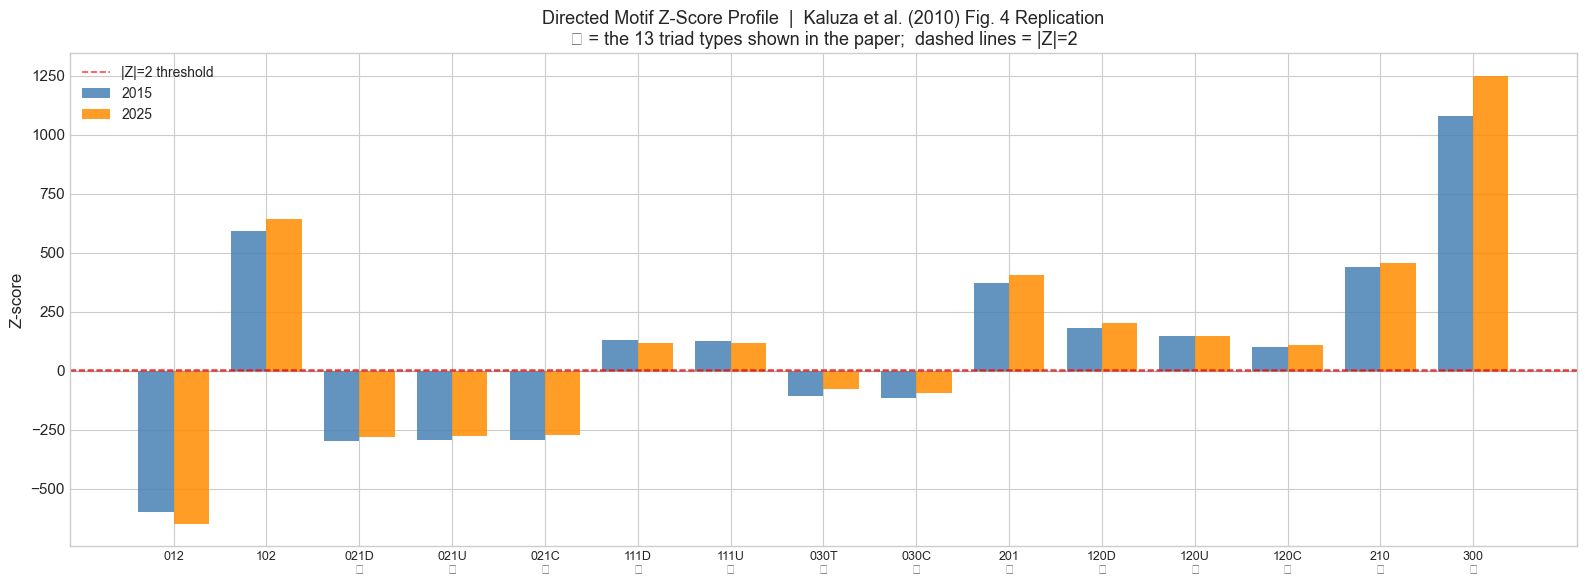

In [6]:
z_15 = df_z15.set_index('Triad')['Z-score']
z_25 = df_z25.set_index('Triad')['Z-score']

x = np.arange(len(TRIAD_TYPES))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 6))
bars15 = ax.bar(x - width/2, [z_15[t] for t in TRIAD_TYPES],
                width, label='2015', color='steelblue', alpha=0.85)
bars25 = ax.bar(x + width/2, [z_25[t] for t in TRIAD_TYPES],
                width, label='2025', color='darkorange', alpha=0.85)

ax.axhline( 2, color='red',  lw=1.2, ls='--', alpha=0.7, label='|Z|=2 threshold')
ax.axhline(-2, color='red',  lw=1.2, ls='--', alpha=0.7)
ax.axhline( 0, color='grey', lw=0.8, ls='-', alpha=0.5)

# Mark the 13 paper motifs with ★ on x-axis
tick_labels = [f'{t}\n★' if t in PAPER_13 else t for t in TRIAD_TYPES]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('Z-score', fontsize=12)
ax.set_title(
    'Directed Motif Z-Score Profile  |  Kaluza et al. (2010) Fig. 4 Replication\n'
    '★ = the 13 triad types shown in the paper;  dashed lines = |Z|=2',
    fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR + '05_motif_zscores.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Paper's 13 Motifs — Zoomed Comparison

Replicates the exact set of motifs shown in Kaluza et al. Fig. 4, highlighting which patterns are significantly over- or under-represented relative to random networks.

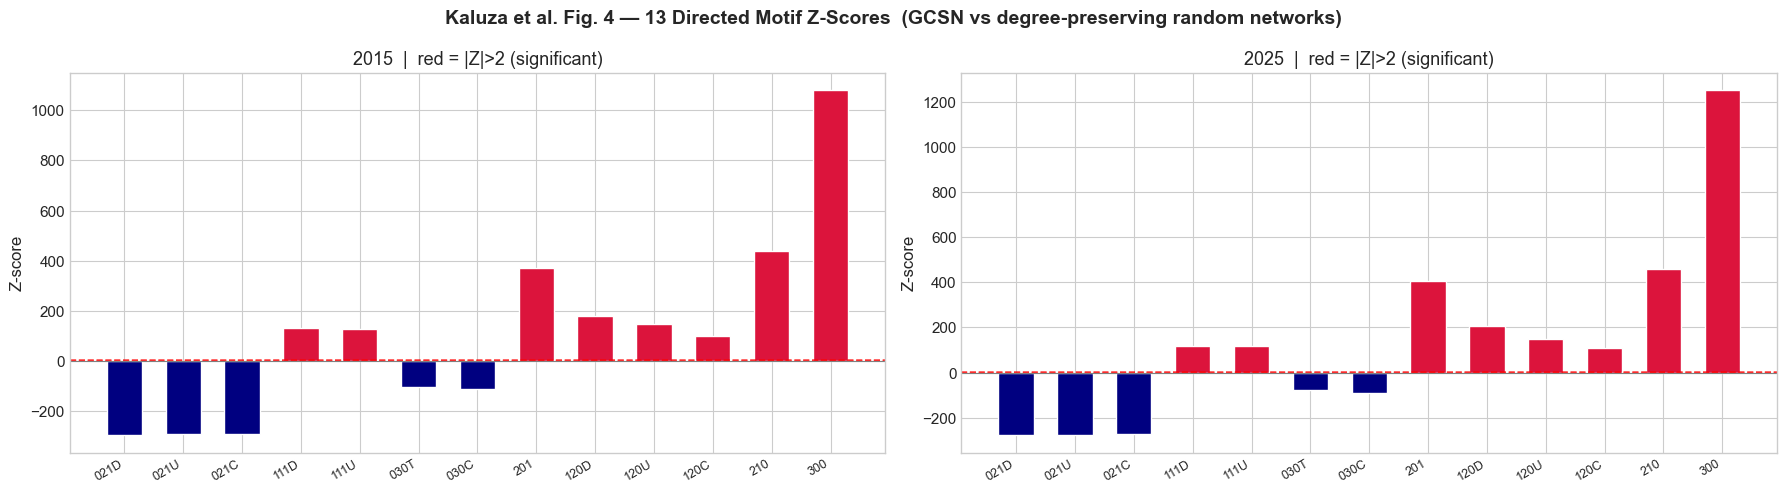

In [7]:
z15_13 = [z_15[t] for t in PAPER_13]
z25_13 = [z_25[t] for t in PAPER_13]

x13 = np.arange(len(PAPER_13))
w   = 0.38

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)
fig.suptitle(
    'Kaluza et al. Fig. 4 — 13 Directed Motif Z-Scores'
    '  (GCSN vs degree-preserving random networks)',
    fontsize=14, fontweight='bold')

for ax, z_vals, year, color in [
    (axes[0], z15_13, '2015', 'steelblue'),
    (axes[1], z25_13, '2025', 'darkorange'),
]:
    bar_colors = ['crimson' if z > 2 else ('navy' if z < -2 else color)
                  for z in z_vals]
    ax.bar(x13, z_vals, color=bar_colors, edgecolor='white', width=0.6)
    ax.axhline( 2, color='red', lw=1.2, ls='--', alpha=0.7)
    ax.axhline(-2, color='red', lw=1.2, ls='--', alpha=0.7)
    ax.axhline( 0, color='grey', lw=0.8)
    ax.set_xticks(x13)
    ax.set_xticklabels(PAPER_13, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Z-score')
    ax.set_title(f'{year}  |  red = |Z|>2 (significant)')

plt.tight_layout()
plt.savefig(FIG_DIR + '05_motif_paper13_zscores.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Absolute Motif Frequencies

Raw (normalized) counts of each triad type in 2015 vs 2025, showing which structural patterns dominate the network.

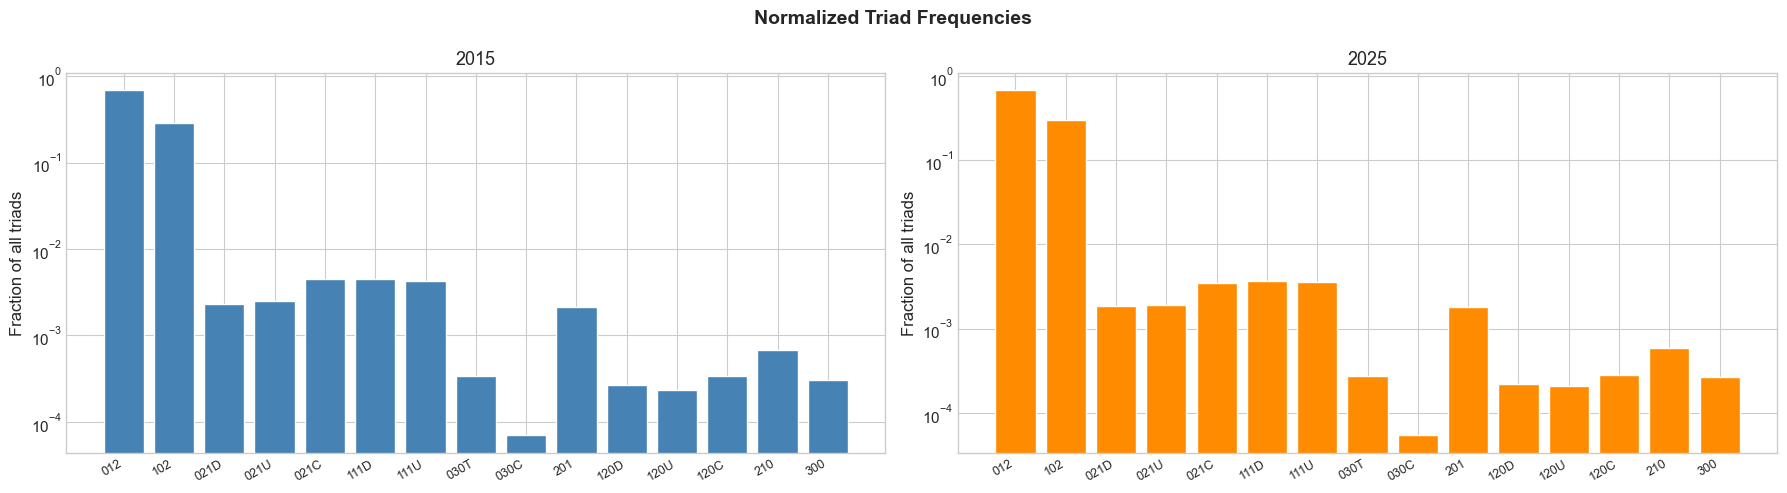

In [8]:
freq15 = np.array([census_2015[t] / total_2015 for t in TRIAD_TYPES])
freq25 = np.array([census_2025[t] / total_2025 for t in TRIAD_TYPES])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Normalized Triad Frequencies', fontsize=14, fontweight='bold')

for ax, freq, year, color in [
    (axes[0], freq15, '2015', 'steelblue'),
    (axes[1], freq25, '2025', 'darkorange'),
]:
    ax.bar(np.arange(len(TRIAD_TYPES)), freq, color=color, edgecolor='white')
    ax.set_xticks(np.arange(len(TRIAD_TYPES)))
    ax.set_xticklabels(TRIAD_TYPES, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Fraction of all triads')
    ax.set_yscale('log')
    ax.set_title(f'{year}')

plt.tight_layout()
plt.savefig(FIG_DIR + '05_motif_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Summary Table

In [9]:
df_summary_m = df_z15[["Triad","Real count","Rand mean","Rand std","Z-score","Over/Under","Paper motif"]].copy()
df_summary_m.columns = ["Triad","Real_2015","RandMean_2015","RandStd_2015","Z_2015","Status_2015","Paper★"]
df_summary_m["Real_2025"] = df_z25["Real count"].values
df_summary_m["Z_2025"]    = df_z25["Z-score"].values
df_summary_m["Status_2025"] = df_z25["Over/Under"].values

print("=" * 110)
print("  GCSN MOTIF ANALYSIS — SUMMARY  |  Kaluza et al. (2010) Fig. 4 Replication")
print("=" * 110)
print(df_summary_m.to_string(index=False))
print("=" * 110)
print()
print("Interpretation:")
print("  030T  (transitive triple): typically over-represented in hierarchical networks")
print("  030C  (3-cycle): over-represented = cyclic routing patterns")
print("  300   (complete triad): over-represented = dense hub clusters")
print("  021D/021U (divergent/convergent star): relate to hub-and-spoke topology")

df_summary_m.to_csv("../Figures/05_motif_summary.csv", index=False)
print("Saved → ../Figures/05_motif_summary.csv")


  GCSN MOTIF ANALYSIS — SUMMARY  |  Kaluza et al. (2010) Fig. 4 Replication
Triad  Real_2015  RandMean_2015  RandStd_2015   Z_2015 Status_2015 Paper★  Real_2025   Z_2025 Status_2025
  012  699285081   1155912809.3     763033.89 -598.437       under         719766316 -648.562       under
  102  287342225     47100811.0     404561.44  593.832        over         315831311  641.611        over
 021D    2318915      8164835.9      19631.29 -297.786       under      ★    1968155 -279.051       under
 021U    2502626      8583265.5      20844.23 -291.718       under      ★    2043509 -275.752       under
 021C    4496812     16270670.3      40088.36 -293.698       under      ★    3700025 -273.572       under
 111D    4581487      2517998.6      15716.78  131.292        over      ★    3866197  116.441        over
 111U    4286981      2427900.6      14530.49  127.943        over      ★    3821197  118.636        over
 030T     341534       879634.8       5131.10 -104.870       under      ★   